# Customer Segmentation and RFM Analysis

## Project Overview

This project analyzes customer purchasing behavior for the Olist Brazilian
e-commerce marketplace. PostgreSQL is used to store, clean, and aggregate the
transaction data. Python is used to validate the customer-level dataset,
calculate RFM scores, create customer segments, and visualize the results.

### Business Objective

The objective is to identify valuable, loyal, promising, at-risk, and inactive
customers so that the business can design more targeted retention and marketing
strategies.

In [1]:
import getpass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import URL, create_engine, text

In [2]:
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

pandas version: 3.0.5
NumPy version: 2.5.1


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## Database Connection

The notebook connects to the PostgreSQL `olist_rfm` database and retrieves the
customer-level RFM table created during the SQL analysis.

In [4]:
database_password = getpass.getpass("Enter your PostgreSQL password: ")

connection_url = URL.create(
    drivername="postgresql+psycopg",
    username="postgres",
    password=database_password,
    host="localhost",
    port=5432,
    database="olist_rfm",
)

engine = create_engine(connection_url)

Enter your PostgreSQL password:  ········


In [5]:
try:
    with engine.connect() as connection:
        database_name = connection.execute(
            text("SELECT current_database();")
        ).scalar()

    print(f"Successfully connected to database: {database_name}")

except Exception as error:
    print("Database connection failed.")
    print(type(error).__name__)
    print(error)

Successfully connected to database: olist_rfm


## Load the Customer-Level RFM Dataset

The SQL-generated `customer_rfm` table contains one row per unique customer.
Only delivered orders with matching payment records are included.

In [6]:
rfm_query = """
SELECT
    customer_unique_id,
    customer_city,
    customer_state,
    last_order_date,
    rfm_analysis_date,
    recency_days,
    frequency,
    monetary
FROM olist.customer_rfm;
"""

rfm = pd.read_sql_query(
    sql=rfm_query,
    con=engine,
    parse_dates=["last_order_date", "rfm_analysis_date"],
)

In [7]:
rfm.head()

,customer_unique_id,customer_city,customer_state,last_order_date,rfm_analysis_date,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,SP,2018-05-10,2018-08-30,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,osasco,SP,2018-05-07,2018-08-30,115,1,27.19
2,0000f46a3911fa3c0805444483337064,sao jose,SC,2017-03-10,2018-08-30,538,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,belem,PA,2017-10-12,2018-08-30,322,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,sorocaba,SP,2017-11-14,2018-08-30,289,1,196.89


In [8]:
print(f"Rows: {rfm.shape[0]:,}")
print(f"Columns: {rfm.shape[1]}")

Rows: 93,357
Columns: 8


In [9]:
list(rfm)

['customer_unique_id',
 'customer_city',
 'customer_state',
 'last_order_date',
 'rfm_analysis_date',
 'recency_days',
 'frequency',
 'monetary']

In [10]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 93357 entries, 0 to 93356
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   customer_unique_id  93357 non-null  str          
 1   customer_city       93357 non-null  str          
 2   customer_state      93357 non-null  str          
 3   last_order_date     93357 non-null  datetime64[s]
 4   rfm_analysis_date   93357 non-null  datetime64[s]
 5   recency_days        93357 non-null  int64        
 6   frequency           93357 non-null  int64        
 7   monetary            93357 non-null  float64      
dtypes: datetime64[s](2), float64(1), int64(2), str(3)
memory usage: 5.7 MB


## Data Validation

Before performing customer segmentation, we validate the RFM dataset by checking:
- Missing values
- Duplicate customers
- Statistical distribution
- Invalid RFM values

In [11]:
rfm.isnull().sum()

customer_unique_id    0
customer_city         0
customer_state        0
last_order_date       0
rfm_analysis_date     0
recency_days          0
frequency             0
monetary              0
dtype: int64

In [12]:
rfm["customer_unique_id"].duplicated().sum()

np.int64(0)

In [13]:
rfm.duplicated().sum()

np.int64(0)

In [14]:
rfm.describe()

,last_order_date,rfm_analysis_date,recency_days,frequency,monetary
count,93357,93357,"93,357.00","93,357.00","93,357.00"
mean,2018-01-03 12:37:45,2018-08-30 00:00:00,238.47,1.03,165.20
min,2016-10-03 00:00:00,2018-08-30 00:00:00,1.00,1.00,9.59
25%,2017-09-17 00:00:00,2018-08-30 00:00:00,115.00,1.00,63.06
50%,2018-01-23 00:00:00,2018-08-30 00:00:00,219.00,1.00,107.78
75%,2018-05-07 00:00:00,2018-08-30 00:00:00,347.00,1.00,182.56
max,2018-08-29 00:00:00,2018-08-30 00:00:00,696.00,15.00,"13,664.08"
std,NaN,NaN,152.59,0.21,226.31


In [15]:
rfm["frequency"].value_counts().sort_index()

frequency
1     90556
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [17]:
one_time_percentage = (
    (rfm["frequency"] == 1).mean() * 100
)

print(
    f"Customers with only one purchase: {one_time_percentage:.2f}%"
)

Customers with only one purchase: 97.00%


In [18]:
print("Negative recency:")
print((rfm["recency_days"] < 0).sum())

print("\nZero frequency:")
print((rfm["frequency"] <= 0).sum())

print("\nNegative monetary:")
print((rfm["monetary"] < 0).sum())

Negative recency:
0

Zero frequency:
0

Negative monetary:
0


In [19]:
print("First purchase:")
print(rfm["last_order_date"].min())

print("\nLatest purchase:")
print(rfm["last_order_date"].max())

print("\nAnalysis date:")
print(rfm["rfm_analysis_date"].unique())

First purchase:
2016-10-03 00:00:00

Latest purchase:
2018-08-29 00:00:00

Analysis date:
<DatetimeArray>
['2018-08-30 00:00:00']
Length: 1, dtype: datetime64[s]


## Data Validation Findings

The customer-level RFM dataset successfully passed validation checks.

### Dataset Overview

- Total customers analyzed: 93,357
- Total columns: 8
- Duplicate customers: 0
- Duplicate rows: 0
- Missing values: 0

### RFM Metric Validation

- Negative recency values: 0
- Zero/invalid frequency values: 0
- Negative monetary values: 0

### Purchase Behavior Findings

- Analysis period:
    - First delivered purchase: 2016-10-03
    - Latest delivered purchase: 2018-08-29
    - RFM analysis date: 2018-08-30

- Average customer recency: approximately 238 days
- Average purchase frequency: 1.03 orders
- Average customer spending: $165.20

### Customer Loyalty Observation

97% of customers made only one purchase.

This indicates that the marketplace has a very high proportion of one-time buyers, creating an opportunity for customer retention strategies focused on encouraging repeat purchases.

In [22]:
!pip install scipy

  Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl (36.6 MB)


In [23]:
import scipy

print(scipy.__version__)

1.18.0


In [24]:
rfm["recency_score"] = pd.qcut(
    rfm["recency_days"],
    q=5,
    labels=[5,4,3,2,1]
)

rfm["recency_score"] = rfm["recency_score"].astype(int)

In [25]:
rfm["recency_score"].value_counts().sort_index()

recency_score
1    18604
2    18471
3    18723
4    18757
5    18802
Name: count, dtype: int64

In [26]:
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1,2,3,4,5]
)

rfm["monetary_score"] = rfm["monetary_score"].astype(int)

In [27]:
rfm["monetary_score"].value_counts().sort_index()

monetary_score
1    18673
2    18683
3    18658
4    18675
5    18668
Name: count, dtype: int64

In [28]:
def frequency_score(value):
    if value == 1:
        return 1
    elif value == 2:
        return 3
    elif value == 3:
        return 4
    else:
        return 5


rfm["frequency_score"] = rfm["frequency"].apply(frequency_score)

In [29]:
rfm[
    [
        "recency_days",
        "frequency",
        "monetary",
        "recency_score",
        "frequency_score",
        "monetary_score"
    ]
].head(20)

,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score
0,112,1,141.90,4,1,4
1,115,1,27.19,4,1,1
2,538,1,86.22,1,1,2
3,322,1,43.62,2,1,1
4,289,1,196.89,2,1,4
5,147,1,166.98,4,1,4
6,132,1,35.38,4,1,1
7,183,1,419.18,3,1,5
8,544,1,150.12,1,1,4
9,171,1,129.76,4,1,3


In [30]:
rfm["rfm_score"] = (
    rfm["recency_score"].astype(str)
    + rfm["frequency_score"].astype(str)
    + rfm["monetary_score"].astype(str)
)

rfm["rfm_score"].head()

0    414
1    411
2    112
3    211
4    214
Name: rfm_score, dtype: str

In [31]:
rfm["rfm_total_score"] = (
    rfm["recency_score"]
    + rfm["frequency_score"]
    + rfm["monetary_score"]
)

rfm["rfm_total_score"].describe()

count   93,357.00
mean         7.07
std          2.10
min          3.00
25%          6.00
50%          7.00
75%          9.00
max         15.00
Name: rfm_total_score, dtype: float64

In [32]:
rfm.sort_values(
    "rfm_total_score",
    ascending=False
).head(10)

,customer_unique_id,customer_city,customer_state,last_order_date,rfm_analysis_date,recency_days,frequency,monetary,recency_score,monetary_score,frequency_score,rfm_score,rfm_total_score
21006,397b44d5bb99eabf54ea9c2b41ebb905,niteroi,RJ,2018-06-17,2018-08-30,74,4,"1,756.53",5,5,5,555,15
73126,c8460e4251689ba205045f3ea17884a1,porto alegre,RS,2018-08-08,2018-08-30,22,4,"4,655.91",5,5,5,555,15
20951,394ac4de8f3acb14253c177f0e15bc58,sao paulo,SP,2018-08-15,2018-08-30,15,5,745.41,5,5,5,555,15
36331,6358b15ef7fa9b1210f1a5735cabd3d9,sao paulo,SP,2018-06-04,2018-08-30,87,4,311.14,5,5,5,555,15
44328,795c1622cf7a53d63d324e862349d01c,curitiba,PR,2018-08-17,2018-08-30,13,4,354.23,5,5,5,555,15
28651,4e65032f1f574189fb793bac5a867bbc,sao caetano do sul,SP,2018-06-14,2018-08-30,77,5,490.41,5,5,5,555,15
92817,fe81bb32c243a86b2f86fbf053fe6140,sao paulo,SP,2018-06-21,2018-08-30,70,5,"1,590.76",5,5,5,555,15
73920,ca77025e7201e3b30c44b472ff346268,recife,PE,2018-06-01,2018-08-30,90,7,"1,122.72",5,5,5,555,15
36706,6469f99c1f9dfae7733b25662e7f1782,santos,SP,2018-06-28,2018-08-30,63,7,758.83,5,5,5,555,15
67407,b896655e2083a1d76b7b85df8fc86e40,francisco morato,SP,2018-07-06,2018-08-30,55,4,507.06,5,5,5,555,15


In [33]:
def segment_customer(row):
    if row["rfm_total_score"] >= 13:
        return "Champions"
    
    elif row["rfm_total_score"] >= 10:
        return "Loyal Customers"
    
    elif row["rfm_total_score"] >= 7:
        return "Potential Loyalists"
    
    elif row["rfm_total_score"] >= 5:
        return "At Risk"
    
    else:
        return "Lost Customers"


rfm["customer_segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [34]:
rfm["customer_segment"].value_counts()

customer_segment
Potential Loyalists    43756
At Risk                25594
Loyal Customers        12270
Lost Customers         11307
Champions                430
Name: count, dtype: int64

In [35]:
rfm["customer_segment"].value_counts(normalize=True) * 100

customer_segment
Potential Loyalists   46.87
At Risk               27.42
Loyal Customers       13.14
Lost Customers        12.11
Champions              0.46
Name: proportion, dtype: float64

## Customer Segmentation Insights

The RFM analysis identified five customer segments among 93,357 customers.

### Key Findings

- Potential Loyalists represent the largest customer group (46.87%).
  These customers have purchasing potential and should receive engagement campaigns
  encouraging repeat purchases.

- At Risk customers represent 27.42% of the customer base.
  These customers have lower recent activity and may require retention campaigns
  such as personalized discounts or reminders.

- Loyal Customers represent 13.14% of customers.
  These customers demonstrate stronger purchasing behavior and should be targeted
  with loyalty programs and cross-selling opportunities.

- Champions represent only 0.46% of customers.
  Although this group is small, they are the highest-value customers and should
  receive VIP treatment to maintain long-term relationships.

- Lost Customers represent 12.11%.
  These customers show low engagement and may require win-back campaigns.

In [41]:
segment_summary = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_unique_id", "count"),
        average_recency=("recency_days", "mean"),
        average_frequency=("frequency", "mean"),
        average_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum")
    )
    .reset_index()
)

segment_summary.sort_values(
    "total_revenue",
    ascending=False
)

,customer_segment,customers,average_recency,average_frequency,average_monetary,total_revenue
4,Potential Loyalists,43756,194.10,1.02,188.41,"8,243,863.54"
3,Loyal Customers,12270,90.45,1.13,346.55,"4,252,159.84"
0,At Risk,25594,305.94,1.00,84.12,"2,152,922.40"
2,Lost Customers,11307,424.89,1.00,50.61,"572,220.84"
1,Champions,430,60.16,2.45,468.13,"201,295.15"


## Segment Performance Insights

### Revenue Opportunity

Potential Loyalists represent the largest opportunity with 43,756 customers
and $8.24M in total revenue. These customers show purchasing potential and
should be targeted with campaigns designed to encourage repeat purchases.

### High-Value Customers

Loyal Customers and Champions demonstrate stronger engagement. Champions have
the highest average monetary value ($468.13) and purchase frequency, making them
ideal candidates for VIP programs and retention strategies.

### Retention Opportunity

At Risk customers represent 27.42% of the customer base. Their lower recent
activity suggests that targeted retention campaigns could prevent further
customer loss.

### Business Recommendation

The company should prioritize converting Potential Loyalists into Loyal
Customers while maintaining relationships with Champions and reducing churn
among At Risk customers.

## Customer Segment Distribution

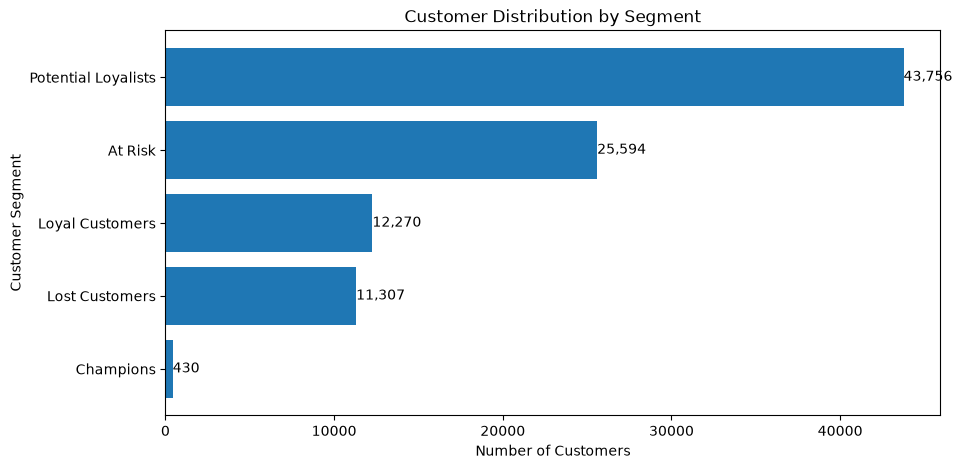

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

segment_counts = (
    rfm["customer_segment"]
    .value_counts()
    .sort_values()
)

bars = plt.barh(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center"
    )

plt.show()

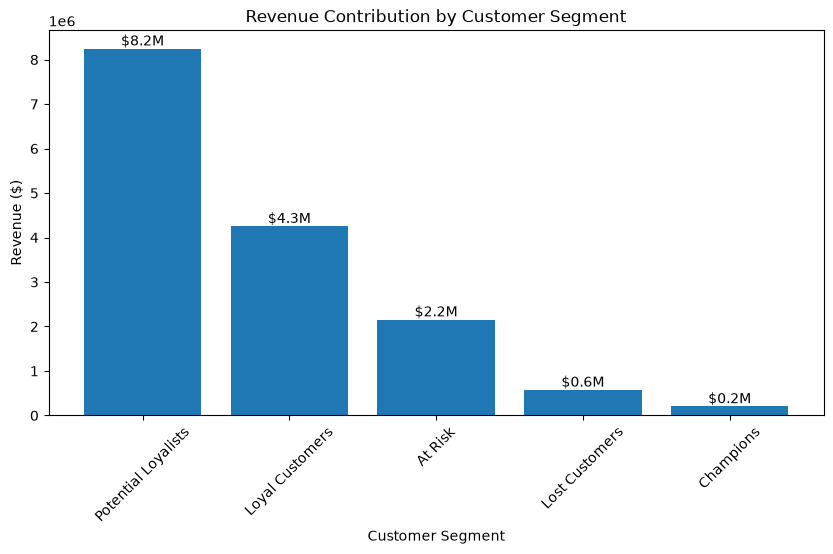

In [45]:
plt.figure(figsize=(10,5))

revenue = (
    segment_summary
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

bars = plt.bar(
    revenue["customer_segment"],
    revenue["total_revenue"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue ($)")

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height/1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

plt.show()

## Export Final Datasets

The final datasets will be exported for Power BI visualization and reporting.

In [46]:
import os

os.makedirs("../outputs", exist_ok=True)

In [47]:
rfm.to_csv(
    "../outputs/customer_rfm_final.csv",
    index=False
)

print("Customer RFM dataset exported successfully.")

Customer RFM dataset exported successfully.


In [48]:
segment_summary.to_csv(
    "../outputs/segment_summary.csv",
    index=False
)

print("Segment summary exported successfully.")

Segment summary exported successfully.


In [49]:
import os

os.listdir("../outputs")

['customer_rfm_final.csv', 'segment_summary.csv']

In [50]:
customer_check = pd.read_csv(
    "../outputs/customer_rfm_final.csv"
)

segment_check = pd.read_csv(
    "../outputs/segment_summary.csv"
)

print(customer_check.shape)
print(segment_check.shape)

(93357, 14)
(5, 6)


In [51]:
customer_check.columns

Index(['customer_unique_id', 'customer_city', 'customer_state',
       'last_order_date', 'rfm_analysis_date', 'recency_days', 'frequency',
       'monetary', 'recency_score', 'monetary_score', 'frequency_score',
       'rfm_score', 'rfm_total_score', 'customer_segment'],
      dtype='str')

In [52]:
segment_check.columns

Index(['customer_segment', 'customers', 'average_recency', 'average_frequency',
       'average_monetary', 'total_revenue'],
      dtype='str')